Imports

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Constants and Global variables

In [3]:
# Constants
EXPRESSION_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Tanaka2014\\Expression_TE_DESeq.csv"
DEA_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Tanaka2014\\DEA_TE_DESeq.csv"
CLINICAL_DATA = "C:\\Users\\Ana\\Documents\\Estágio\\Tanaka2014\\SraRunTable_Tanaka2014.csv"
INTERGENIC_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Tanaka2014\\TE_Intergenic_With_Distances.bed"

# Variables
expression_df = None
dea_df = None
genes_of_interest = None

Expression - Import

In [4]:
expression_df = pd.read_csv(EXPRESSION_FILE)
expression_df.rename(columns = {'Unnamed: 0' : 'TE'}, inplace = True)
expression_df.head()

,TE,GSM1249124,GSM1249126,GSM1249130,GSM1249122,GSM1249123,GSM1249128,GSM1249129
0,TE_AluSq2_dup2,1,1,5,0,1,3,1
1,TE_AluJr_dup7,0,5,3,0,1,1,4
2,TE_MLT1D_dup4,2,1,4,4,0,0,4
3,TE_Charlie15a_dup1,2,7,22,6,2,5,59
4,TE_L3_dup6,3,4,2,8,4,4,11


DEA - Import

In [5]:
dea_df = pd.read_csv(DEA_FILE)
dea_df.rename(columns = {'Unnamed: 0' : 'TE'}, inplace = True)
dea_df.dropna(subset =['padj'], inplace = True)
dea_df.head()

,TE,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,TE_LTR41B_dup333,307.564377,-12.651281,1.125039,-11.245196,2.445518e-29,1.541312e-24
1,TE_L1PA8_dup1210,1483.677588,3.549181,0.390415,9.090787,9.832460e-20,3.098503e-15
2,TE_7SK_dup524,70.484808,-5.020849,0.599394,-8.376545,5.450387e-17,1.145054e-12
3,TE_L1PA17_dup1804,491.966562,9.554138,1.195320,7.992953,1.317444e-15,2.075831e-11
4,TE_MER41B_dup1879,726.557538,-6.187572,0.801886,-7.716273,1.197808e-14,1.509861e-10


Volcano plot

Classification
Non-significant    62346
Down-regulated       538
Up-regulated         142
Name: count, dtype: int64
Total tes:
185977
15938
         0         1         2                    TE      4  5     6     7  \
0     chr1   4180996   4185574     TE_HERVH-int_dup1  34034  -  ERV1   LTR   
1     chr1   4185553   4187477     TE_HERVH-int_dup2  13268  -  ERV1   LTR   
2     chr1   5044795   5045235          TE_LTR7_dup3   3350  +  ERV1   LTR   
3     chr1   5045237   5048268     TE_HERVH-int_dup3  20615  +  ERV1   LTR   
4     chr1   5048383   5052649     TE_HERVH-int_dup5  29309  +  ERV1   LTR   
...    ...       ...       ...                   ...    ... ..   ...   ...   
4945  chrY  18640472  18640627       TE_L1M1_dup9814    312  -    L1  LINE   
4946  chrY  18642331  18642597       TE_L1M1_dup9816    503  -    L1  LINE   
4947  chrY  19419024  19427239  TE_HERVH-int_dup5956  24462  +  ERV1   LTR   
4948  chrY  19834098  19840237     TE_L1PA4_dup12182  24414  -    L1  LINE   
49

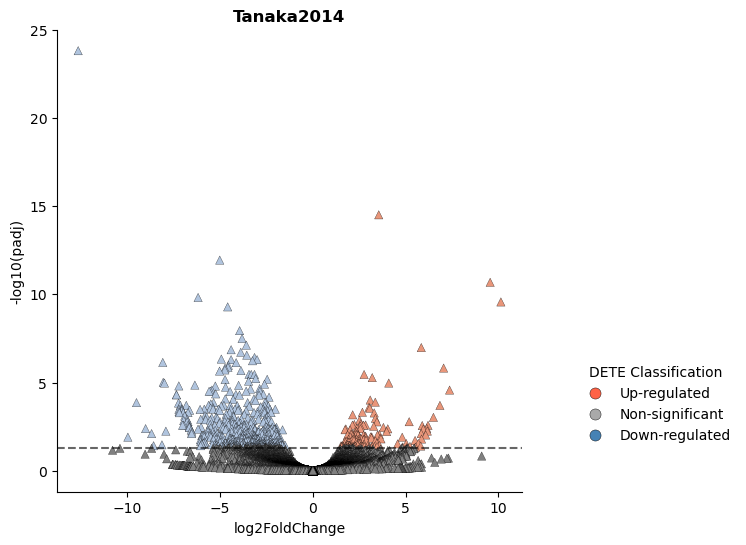

In [6]:

# Organizes the classification, according to the defined values
def organize_classification():
    dea_df['-log10(padj)'] = -np.log10(dea_df['padj'])

    dea_df['Classification'] = dea_df.apply(
        lambda row:
        'Up-regulated' if (row['log2FoldChange'] > 0 and row['padj'] < 0.05)
        else 'Down-regulated' if (row['log2FoldChange'] < -0 and row['padj'] < 0.05)
        else 'Non-significant',
        axis = 1
    )

# Sets the graph's reference lines and labels
def set_lines_and_labels(ax):
    ax.axhline(y = -np.log10(0.05), color = 'black', linestyle = '--', alpha = 0.6)

    ax.set_title('Tanaka2014', fontweight = 'bold', fontsize = 12)
    ax.set_xlabel('log2FoldChange')
    ax.set_ylabel('-log10(padj)')

# Gets the genes with the biggest change in expression
def get_genes_of_interest():
    significant_df = dea_df[dea_df['Classification'] != 'Non-significant']
    top_up = significant_df.nlargest(5, 'log2FoldChange')['TE'].tolist()
    top_down = significant_df.nsmallest(5, 'log2FoldChange')['TE'].tolist()
    genes_of_interest = top_up + top_down

    dea_df['Classification'] = np.where(dea_df['TE'].isin(genes_of_interest), 
                                        'GOI_' + dea_df['Classification'],
                                        dea_df['Classification'])
    
    return genes_of_interest

# Sets the genes of interest's names on the graph
def set_genes_of_interest_legend(ax):
    global genes_of_interest
    genes_of_interest = get_genes_of_interest()
    texts = []
    for i, row in dea_df.iterrows():
        if row['TE'] in genes_of_interest:
            texts.append(ax.text(row['log2FoldChange'], row['-log10(padj)'], row['TE'],
                         fontsize = 7, color = 'black', fontweight = 'semibold'))
            
    adjust_text(texts, expand_points = (1.5, 1.5), arrowprops = dict(arrowstyle = '-', color = 'black', lw = 0.8), save_steps = False)
    print(texts)

# Sets the main chart legend on the plot
def set_plot_legends(ax):
    #set_genes_of_interest_legend(ax)
    legend_elements = [Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'tomato',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3, 
                            label = 'Up-regulated'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'darkgray',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Non-significant'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'steelblue',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Down-regulated')]
    ax.legend(handles = legend_elements, title = 'DETE Classification', bbox_to_anchor = (1.1, 0.3), frameon = False)

# Main function, gets the volcano plot
def get_volcano_plot():
    organize_classification() # Organiza-se primeiro a tabela com a classificação
    print(dea_df['Classification'].value_counts())
    
    print('Total tes:')
    print(len(expression_df))
    
    intergenic_df = pd.read_csv(INTERGENIC_FILE, sep = '\t', header = None, comment = '#')
    intergenic_df = intergenic_df[intergenic_df.iloc[:, -1] > 4000]
    print(intergenic_df.shape[0])

    intergenic_df = intergenic_df.rename(columns = {intergenic_df.columns[3] : 'TE'})
    intergenic_dete_df = intergenic_df.merge(dea_df, on = 'TE', how = 'inner')
    print(intergenic_dete_df)
    intergenic_dete_df = intergenic_dete_df[intergenic_dete_df['Classification'] != 'Non-significant']
    print('intergenic dete')
    print(intergenic_dete_df.shape[0])

    fig, ax = plt.subplots(figsize = (6, 6)) # Criamos o gráfico
    
    palette_dea = {'GOI_Up-regulated' : 'tomato',
                   'GOI_Down-regulated' : 'steelblue',
                   'Up-regulated' : 'darksalmon',
                   'Down-regulated' : 'lightsteelblue',
                   'Non-significant' : 'gray'}
    
    sns.scatterplot(data = dea_df,  
                    x = 'log2FoldChange', 
                    y = '-log10(padj)',
                    palette = palette_dea, 
                    hue = 'Classification', 
                    edgecolor = 'black',
                    linewidth = 0.2, 
                    legend = False, marker = '^')
    
    set_lines_and_labels(ax) # Colocamos as labels que queremos
    set_plot_legends(ax) # Colocamos as legendas por último
    sns.despine()
    plt.show()
    
get_volcano_plot()



PCA - Data frame

In [7]:
# Variables
TEs = expression_df.iloc[:, 0]
counts = expression_df.iloc[:, 1:]
clinical_data = pd.read_csv(CLINICAL_DATA)

# Process counts
library_size = counts.sum(axis = 0)
cpm_df = counts.div(library_size, axis = 1) * 1e6
log2cpm_df = np.log2(cpm_df + 1)
print(log2cpm_df.head())

# Process clinical data

clinical_data['Condition'] = clinical_data['mutation'].apply(lambda x: 'WT' if x == 'no' else 'RTT')
clinical_data.loc[clinical_data['treatment'] != 'no', 'Condition'] = 'shMECP2'
clinical_data.loc[ clinical_data['Run'].isin(['SRR1015689', 'SRR1015687', 'SRR1015691', 'SRR1015690']) |
                  (clinical_data['mutation'] == 'no')
                  ]

clinical_data = clinical_data[clinical_data['Condition'].isin(['WT', 'RTT'])]
clinical_data = clinical_data[['Sample Name', 'Condition', 'Run', 'mutation']]

# Scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log2cpm_df.T)

pca = PCA(n_components = 2)
pca_res = pca.fit_transform(scaled_data)

# PCA data frame
pca_df = pd.DataFrame(pca_res, index = log2cpm_df.columns, columns = [f"PC{i+1}" for i in range(2)])
pca_df.reset_index(names = 'Sample Name', inplace = True)
pca_df = pca_df.merge(clinical_data, on = 'Sample Name', how = 'left')

pca_df.head()

   GSM1249124  GSM1249126  GSM1249130  GSM1249122  GSM1249123  GSM1249128  \
0    0.880590    0.408881    0.867187    0.000000    0.990015    1.394262   
1    0.000000    1.399597    0.579626    0.000000    0.990015    0.625595   
2    1.423447    0.408881    0.730560    1.821120    0.000000    0.000000   
3    1.423447    1.719662    2.209782    2.263134    1.571634    1.893065   
4    1.816961    1.208282    0.411037    2.601009    2.305919    1.665114   

   GSM1249129  
0    0.302735  
1    0.951530  
2    0.951530  
3    3.885121  
4    1.835232  


,Sample Name,PC1,PC2,Condition,Run,mutation
0,GSM1249124,172.918944,-168.562202,WT,SRR1015685,no
1,GSM1249126,-459.562606,41.446652,RTT,SRR1015687,X487W
2,GSM1249130,-6.324752,23.500852,RTT,SRR1015691,R306C
3,GSM1249122,125.940782,-132.383326,WT,SRR1015683,no
4,GSM1249123,34.574428,-245.271523,WT,SRR1015684,no


PCA - Graph

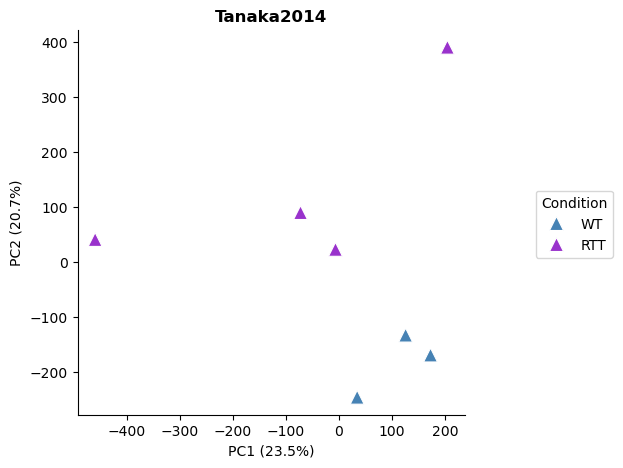

In [8]:
fig, ax = plt.subplots(figsize = (5, 5))
palette_pca = {'WT' : 'steelblue',
               'RTT' : 'darkorchid'}

sns.scatterplot(data = pca_df, x = 'PC1', y = 'PC2', palette = palette_pca, hue = 'Condition', s = 100, marker = '^')
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)") # f-string é uma forma moderna de formatar strings em python, valor da variância * 100 para meter em percentagem e dps coloca só com uma casa decimal
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Tanaka2014", fontweight = 'bold', fontsize = 12)
ax.legend(title = 'Condition', bbox_to_anchor = (1.4, 0.6))
sns.despine()
plt.show()


Boxplot

In [9]:
# Assemble the new table
log2cpm_df.insert(0, 'TE', TEs)
goi_df = log2cpm_df[log2cpm_df['TE'].isin(genes_of_interest)]

long_df = goi_df.melt(id_vars = 'TE', var_name = 'Sample Name', value_name = 'log2(CPM)')
long_df = long_df.merge(clinical_data, on = 'Sample Name', how = 'left')

print(clinical_data.head())

# Assemble the plot

fig, ax = plt.subplots(figsize = (12, 12))

palette_boxplot = {'RTT' : 'tomato',
                   'WT' : 'steelblue'}

sns.boxplot(data = long_df, x = 'TE', y = 'log2(CPM)', hue = 'Condition', palette = palette_boxplot,
                fliersize = 2, linewidth = 2)

ax.set_title('Boxplot - TEs - Tanaka', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('TEs')
ax.set_ylabel('log2(CPM)')
ax.tick_params(axis = 'x', rotation = 45)



TypeError: only list-like objects are allowed to be passed to isin(), you passed a `NoneType`